<a href="https://colab.research.google.com/github/CrushHour/Medizin/blob/main/SoSe26_Hausaufgabe1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Laden der Daten in ein dictionary

Netflix! Was 1997 als DVD-Verleih begann, hat sich seither zum größten Unterhaltungs- und Medienunternehmen nach Marktkapitalisierung entwickelt, das im Januar 2021 über 200 Millionen Abonnenten hatte.

Angesichts der großen Anzahl von Filmen und Serien, die auf der Plattform verfügbar sind, ist dies eine perfekte Gelegenheit, unsere Fähigkeiten in der Datenmanipulation zu testen, die wir in den ersten zwei Wahlfachterminen erlernt haben!

Im folgenden werden wir mit einer CSV-Datei mit Netflix-Daten arbeiten und analysieren, ob die durchschnittliche Dauer von Filmen abgenommen hat.

Als Beweis dafür haben wir folgende Informationen zur Verfügung: Für die Jahre 2011 bis 2020 liegt die durchschnittliche Filmdauer bei 103, 101, 99, 100, 100, 95, 95, 96, 93 bzw. 90.

Datenanalyse und -manipulation geht am einfachsten mit der pandas library. Aber zuerst müssen wir ein DataFrame von Grund auf erstellen. Beginnen wir daher zunächst mit der Erstellung eines Python-Objekts: einem Wörterbuch!

In [1]:
# Create the years and durations lists
years = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
durations = [103, 101, 99, 100, 100, 95, 95 , 96, 93, 90]

# Create a dictionary with the two lists
movie_dict = {"years": years, "durations": durations}

# Print the dictionary
movie_dict

{'years': [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020],
 'durations': [103, 101, 99, 100, 100, 95, 95, 96, 93, 90]}

## 2. Erstellen eines DataFrame aus einem Wörterbuch

Um unser dictionary movie_dict in einen Pandas DataFrame zu konvertieren, müssen wir zunächst die library unter ihrem üblichen Alias importieren. Außerdem müssen wir unseren DataFrame überprüfen, um sicherzustellen, dass dieser korrekt erstellt wurde:

In [3]:
# Import pandas under its usual alias
import pandas as pd

# Create a DataFrame from the dictionary
durations_df = pd.DataFrame(movie_dict)

# Print the DataFrame

durations_df

,years,durations
0,2011,103
1,2012,101
2,2013,99
3,2014,100
4,2015,100
5,2016,95
6,2017,95
7,2018,96
8,2019,93
9,2020,90


## 3. Visuelle Darstellung unserer Daten
Sehr gut, wir haben jetzt einen Pandas DataFrame, die gängigste Art, mit tabular data in Python zu arbeiten. Nun zurück zu unserer Aufgabe. Wir wollen der Behauptung nachgehen, dass die Filmlänge im Laufe der Zeit abgenommen hat. Durch eine Visualisierung der Daten können wir einene ersten Trend abschätzen.

Da es sich um kontinuierliche Daten handelt, wäre ein line plot eine gute Wahl, bei dem die years auf der x-Achse und die durations in Minuten auf der y-Achse dargestellt werden. Auf diese Weise lassen sich Trends in der Filmdauer leicht erkennen. Es gibt viele Möglichkeiten, Daten in Python zu visualisieren, aber matploblib.pyplot ist eines der gebräuchlichsten Pakete, um dies zu tun.

Hinweis: Damit wir Ihre Darstellung korrekt testen können, müsst ihr ein matplotlib.pyplot Figure-Objekt initialisieren, das ich euch bereits in der Zelle unten bereitgestellt habe.

Matplotlib is building the font cache; this may take a moment.


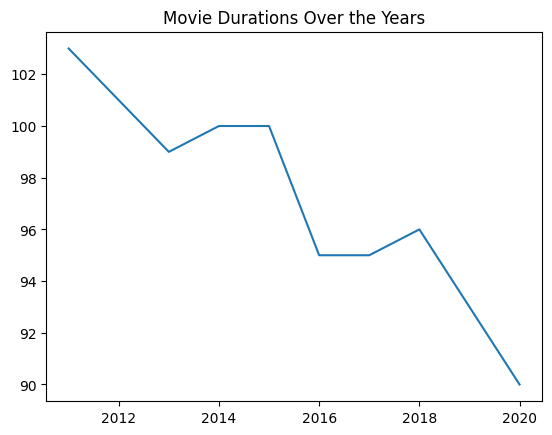

In [4]:
# Import matplotlib.pyplot under its usual alias and create a figure
import matplotlib.pyplot as plt
fig = plt.figure()

# Draw a line plot of release_years and durations
plt.plot(durations_df["years"], durations_df["durations"])

# Create a title
plt.title("Movie Durations Over the Years")

# Show the plot
plt.show()

## 4. Laden der restlichen Daten aus einer CSV-Datei

Es sieht tatsächlich danach aus, als ob etwas an der These dran ist, dass die Filmlänge in den letzten zehn Jahren abgenommen hat! Um dieser These weiter nachzugehen, müssen wir die Analysen ausweiten.

Wir haben nun Zugriff auf die CSV-Datei, die deutlich mehr Spielraum für Analysen bietet. Wir erstellen nun einen weiteren DataFrame und werfen einen ersten Blick auf diesen, indem wir die ersten fünf Zeilen ausgeben lassen.

In [7]:
# Read in the CSV as a DataFrame
url = 'https://raw.githubusercontent.com/VanishingRasengan/WahlfachKISoSe23/main/datasets/netflix_data.csv'
netflix_df = pd.read_csv(url)

# Print the first five rows of the DataFrame
netflix_df[:5]

,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,4,In a future where the elite inhabit an island ...,International TV
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,93,After a devastating earthquake hits Mexico Cit...,Dramas
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,78,"When an army recruit is found dead, his fellow...",Horror Movies
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,80,"In a postapocalyptic world, rag-doll robots hi...",Action
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,123,A brilliant group of students become card-coun...,Dramas


## 5. Filtern nach Filmen!

Super, endlich haben wir unsere Daten! Jetzt können wir eintauchen und uns die Filmlängen genauer anschauen.

Oder können wir das? Wenn wir uns die ersten fünf Zeilen unseres neuen DataFrame ansehen, fällt uns die Spalte "type" auf. Beim Betrachten der Spalte wird deutlich, dass der Datensatz auch Fernsehsendungen enthält! Außerdem scheint die Spalte "duration", die wir verwenden wollten, unterschiedliche Werte zu repräsentieren, je nachdem, ob es sich bei der Zeile um einen Film oder eine Serie handelt (vielleicht die Anzahl der Minuten oder die Anzahl der Staffeln)?

Glücklicherweise ermöglicht ein DataFrame das schnelle Filtern von Daten, und wir können Zeilen auswählen, deren type "Movie" ist. Wenn wir schon dabei sind: Wir brauchen auch nicht die Informationen aus allen Spalten, also erstellen wir einen neuen DataFrame netflix_movies, der nur 'title', 'country', 'genre', 'release_year', 'duration' enthält.

Lassen Sie uns unsere data subsetting skills einsetzen!

In [8]:
# Subset the DataFrame for type "Movie"
netflix_df_movies_only = netflix_df[netflix_df["type"] == "Movie"]

# Select only the columns of interest
netflix_movies_col_subset = netflix_df_movies_only[["title", "country", "genre", "release_year", "duration"]]

# Print the first five rows of the new DataFrame
netflix_movies_col_subset[:5]

,title,country,genre,release_year,duration
1,7:19,Mexico,Dramas,2016,93
2,23:59,Singapore,Horror Movies,2011,78
3,9,United States,Action,2009,80
4,21,United States,Dramas,2008,123
6,122,Egypt,Horror Movies,2019,95


## 6. Creating a scatter plot
Okay, jetzt kommen wir weiter. Wir haben die Rohdaten eingelesen, Filmzeilen ausgewählt und unseren DataFrame auf die für uns interessanten Spalten beschränkt. Versuchen wir nun, die Daten erneut zu visualisieren, um die Daten über einen längeren Zeitraum zu untersuchen.

Diesmal arbeiten wir nicht mehr mit "aggregierten Daten", sondern mit einzelnen Filmen. Ein  line plot ist für unsere Daten daher nicht mehr geeignet, also versuchen wir es stattdessen mit einem scatter plot. Wir werden wieder das Jahr der Veröffentlichung auf der x-Achse und die Filmdauer auf der y-Achse darstellen.

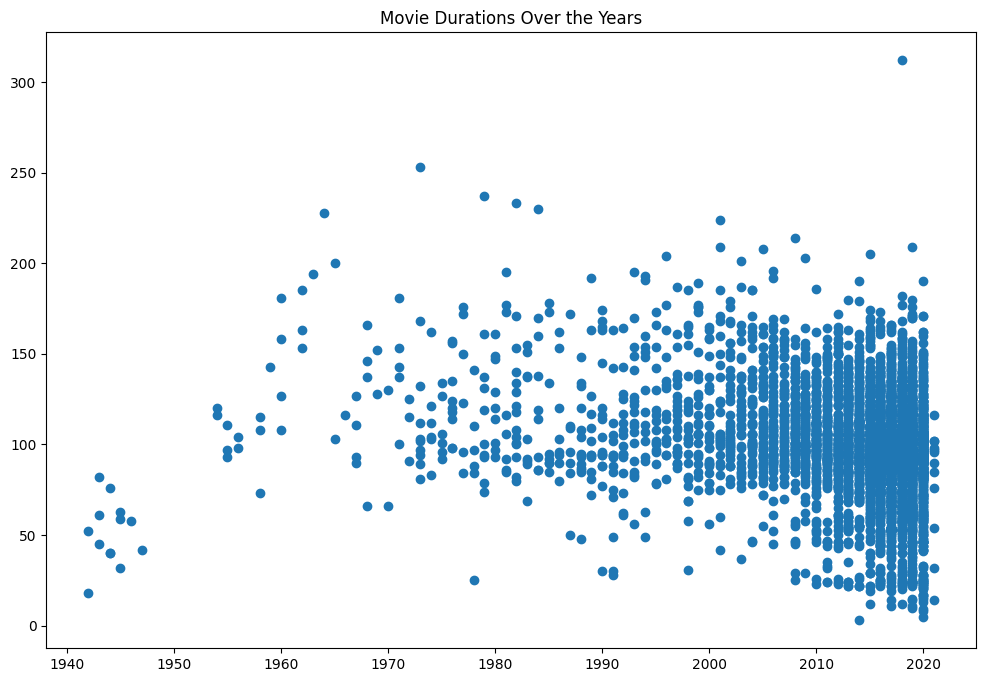

In [9]:
# Create a figure and increase the figure size
fig = plt.figure(figsize=(12,8))

# Create a scatter plot of duration versus year
plt.scatter(netflix_movies_col_subset["release_year"], netflix_movies_col_subset["duration"])

# Create a title
plt.title("Movie Durations Over the Years")

# Show the plot
plt.show()

## 7. Weiter geht's
Das ist schon viel aufschlussreicher als die einfache Grafik, die wir zu Beginn erstellt haben. Wir können auch sehen, dass neuere Filme auf der Plattform überrepräsentiert sind und viele Kurzfilme in den letzten zwei Jahrzehnten veröffentlicht wurden.

Bei näherer Betrachtung fällt noch etwas anderes auf: Einige dieser Filme sind weniger als eine Stunde lang! Filtern wir unseren DataFrame nach Filmen mit einer Dauer von weniger als 60 Minuten und sehen wir uns die Genres an. Dies könnte uns Aufschluss darüber geben, was den Durchschnitt nach unten zieht.

In [10]:
# Filter for durations shorter than 60 minutes
short_movies = netflix_movies_col_subset[netflix_movies_col_subset["duration"] < 60]

# Print the first 20 rows of short_movies
short_movies[:20]

,title,country,genre,release_year,duration
35,#Rucker50,United States,Documentaries,2016,56
55,100 Things to do Before High School,United States,Uncategorized,2014,44
67,13TH: A Conversation with Oprah Winfrey & Ava ...,NaN,Uncategorized,2017,37
101,3 Seconds Divorce,Canada,Documentaries,2018,53
146,A 3 Minute Hug,Mexico,Documentaries,2019,28
162,A Christmas Special: Miraculous: Tales of Lady...,France,Uncategorized,2016,22
171,A Family Reunion Christmas,United States,Uncategorized,2019,29
177,A Go! Go! Cory Carson Christmas,United States,Children,2020,22
178,A Go! Go! Cory Carson Halloween,NaN,Children,2020,22
179,A Go! Go! Cory Carson Summer Camp,NaN,Children,2020,21


## 8. Marking non-feature films
Interessant! Es sieht so aus, als ob viele der Filme, die weniger als 60 Minuten lang sind, in Genres wie "Kinder", "Stand-Up" und "Dokumentarfilme" fallen. Dies ist ein logisches Ergebnis, da diese Arten von Filmen wahrscheinlich oft kürzer sind als 90-minütige Hollywood-Blockbuster.

Wir könnten diese Zeilen aus unserem DataFrame eliminieren und die Werte erneut darstellen. Eine andere interessante Möglichkeit, die Auswirkungen dieser Genres auf unsere Daten zu untersuchen, wäre es, sie zwar miteinzubeziehen, sie jedoch mit einer anderen Farbe zu markieren.

In Python gibt es dafür viele Möglichkeiten, aber ihr sollt das am besten mit einer Schleife üben, um eine Liste von Farben basierend auf dem Inhalt der Genre-Spalte zu erzeugen. Dieser Liste können wir dann in einem späteren Schritt an unsere Plotting-Funktion übergeben, um alle untypischen Genres in einer anderen Farbe zu markieren!

In [15]:
# Define an empty list
colors = []

# Iterate over rows of netflix_movies_col_subset
for _, row in netflix_movies_col_subset.iterrows():
    if row["genre"] == "Children":
        colors.append("red")
    elif row["genre"] == "Documentaries":
        colors.append("blue")
    elif row["genre"] == "Stand-Up":
        colors.append("green")
    else:
        colors.append("white")

# Inspect the first 10 values in your list
colors[:10]

['white',
 'white',
 'white',
 'white',
 'white',
 'white',
 'white',
 'white',
 'white',
 'blue']

## 9. Plotting with color!
Hervorragend! Jetzt haben wir eine Farbliste, die wir an unseren scatter plot übergeben können. Damit können wir visuell überprüfen, ob diese Genres für den Rückgang der durchschnittlichen Filmdauer verantwortlich sein könnten.

Diesmal werden wir auch unser Diagramm mit einigen zusätzlichen Achsenbeschriftungen und einem neuen theme mit plt.style.use() aufhübschen.

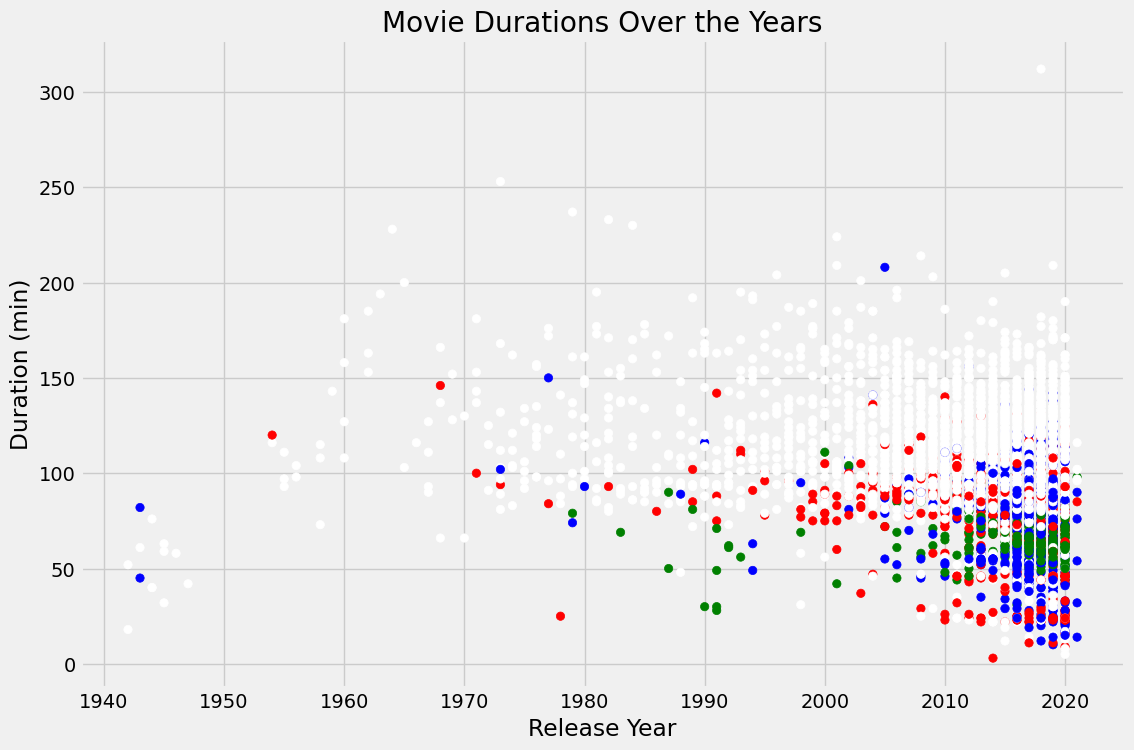

In [16]:
# Set the figure style and initalize a new figure
plt.style.use('fivethirtyeight')
fig = plt.figure(figsize=(12,8))

# Create a scatter plot of duration versus release_year
plt.scatter(netflix_movies_col_subset["release_year"], netflix_movies_col_subset["duration"], c=colors)

# Create a title and axis labels
plt.title("Movie Durations Over the Years")
plt.xlabel("Release Year")
plt.ylabel("Duration (min)")

# Show the plot
plt.show()

## 10. Ausblick
Wie wir vermutet haben, sind die non-typical Genres wie Kinderfilme und Dokumentarfilme alle in der unteren Hälfte des Diagramms angesiedelt. Um unsere These aber wirklich zu beweisen, müssten wir statistische Tests durchführen - aber das ist fast schon ein eigenes Wahlfachthema Wert ;).

Nächste Woche wird es richtig spannend: Wir lernen, lernen was machine-learning überhaupt ist und versuchen einen ersten Algorithmus zu programmieren. Seid gespannt!